# Retail Demand Forecasting

## 9. Final Model Selection and Forecasting

This stage consolidates the forecasting results obtained from the seasonal naive benchmark, SARIMAX, original XGBoost, and tuned XGBoost models.

The final model is selected based on out-of-sample forecasting performance while considering both predictive accuracy and model complexity.

The selected model is then used to generate the final demand forecast for the forecasting horizon.

## 9.1 Load Model Evaluation Results

Previously generated model evaluation outputs are loaded from the project output directory.

Using saved results ensures that the final model selection remains reproducible and independent of notebook execution order.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

OUTPUT_PATH = "outputs/tables"

In [2]:
import os

TABLE_PATH = "outputs/tables"

print("Files available in outputs/tables:")
print("-" * 50)

for file in sorted(os.listdir(TABLE_PATH)):
    print(file)

Files available in outputs/tables:
--------------------------------------------------
.gitignore
annual_sales_summary.csv
baseline_family_results.csv
baseline_results.csv
business_demand_accuracy.csv
business_metrics.csv
business_monthly_sales.csv
business_promotion_summary.csv
business_weekday_sales.csv
correlation_matrix.csv
family_sales_summary.csv
family_volatility.csv
final_error_summary.csv
final_forecast_summary.csv
final_forecast_with_errors.csv
final_model_comparison.csv
final_xgboost_forecast.csv
forecasting_features.csv
holiday_summary.csv
largest_forecast_errors.csv
promotion_summary.csv
sarimax_forecast.csv
sarimax_results.csv
store_sales_summary.csv
xgboost_feature_importance.csv
xgboost_forecast.csv
xgboost_results.csv
xgboost_tuning_comparison.csv
xgboost_tuning_results.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

OUTPUT_PATH = "outputs/tables"

baseline_results = pd.read_csv(
    f"{OUTPUT_PATH}/baseline_results.csv"
)

sarimax_results = pd.read_csv(
    f"{OUTPUT_PATH}/sarimax_results.csv"
)

xgb_results = pd.read_csv(
    f"{OUTPUT_PATH}/xgboost_results.csv"
)

tuning_comparison = pd.read_csv(
    f"{OUTPUT_PATH}/xgboost_tuning_comparison.csv"
)

print("Baseline results:")
display(baseline_results)

print("\nSARIMAX results:")
display(sarimax_results)

print("\nXGBoost results:")
display(xgb_results)

print("\nXGBoost tuning results:")
display(tuning_comparison)

Baseline results:


,Model,MAE,RMSE,MAPE (%)
0,Naive,139.25,550.04,55.82
1,Seasonal Naive,102.19,443.21,52.72



SARIMAX results:


,Model,MAE,RMSE
0,Seasonal Naive,"1,357.77","1,744.01"
1,SARIMAX,"1,889.02","2,420.27"



XGBoost results:


,Model,MAE,RMSE,MAPE
0,XGBoost,641.55,780.44,6.57



XGBoost tuning results:


,Model,MAE,RMSE
0,Original XGBoost,641.55,780.44
1,Tuned XGBoost,818.47,"1,014.53"


## 9.2 Final Model Comparison

The forecasting models are compared using out-of-sample Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

The Seasonal Naive model provides the benchmark, while SARIMAX and XGBoost represent increasingly sophisticated forecasting approaches. The tuned XGBoost model is included to assess whether hyperparameter optimization improves predictive performance.

Lower MAE and RMSE indicate better forecasting accuracy.

In [4]:
# Seasonal Naive and SARIMAX were both evaluated in notebook 06 on the same
# series (Store 45, GROCERY I) and the same 30-day holdout as the XGBoost
# models, so they are the only fair baseline numbers to use here.
# (baseline_results.csv from notebook 05 is scored on ALL series, so it is
# not comparable and is deliberately not used.)
baseline = sarimax_results.loc[sarimax_results["Model"] == "Seasonal Naive"].iloc[0]
sarimax = sarimax_results.loc[sarimax_results["Model"] == "SARIMAX"].iloc[0]

original_xgb = tuning_comparison.loc[
    tuning_comparison["Model"] == "Original XGBoost"
].iloc[0]
tuned_xgb = tuning_comparison.loc[
    tuning_comparison["Model"] == "Tuned XGBoost"
].iloc[0]

final_model_comparison = pd.DataFrame([
    {"Model": "Seasonal Naive",   "MAE": baseline["MAE"],     "RMSE": baseline["RMSE"]},
    {"Model": "SARIMAX",          "MAE": sarimax["MAE"],      "RMSE": sarimax["RMSE"]},
    {"Model": "Original XGBoost", "MAE": original_xgb["MAE"], "RMSE": original_xgb["RMSE"]},
    {"Model": "Tuned XGBoost",    "MAE": tuned_xgb["MAE"],    "RMSE": tuned_xgb["RMSE"]},
])

final_model_comparison

,Model,MAE,RMSE
0,Seasonal Naive,"1,357.77","1,744.01"
1,SARIMAX,"1,889.02","2,420.27"
2,Original XGBoost,641.55,780.44
3,Tuned XGBoost,818.47,"1,014.53"


In [5]:
final_model_comparison = (
    final_model_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
)

final_model_comparison["Rank"] = (
    final_model_comparison.index + 1
)

final_model_comparison

,Model,MAE,RMSE,Rank
0,Original XGBoost,641.55,780.44,1
1,Tuned XGBoost,818.47,"1,014.53",2
2,Seasonal Naive,"1,357.77","1,744.01",3
3,SARIMAX,"1,889.02","2,420.27",4


## 9.3 Final Model Selection

The final forecasting model is selected based on the lowest out-of-sample MAE. RMSE is used as a secondary metric to assess the impact of larger forecasting errors.

In [6]:
final_model = final_model_comparison.iloc[0]["Model"]
final_mae = final_model_comparison.iloc[0]["MAE"]
final_rmse = final_model_comparison.iloc[0]["RMSE"]

print(f"Selected final model: {final_model}")
print(f"Final MAE: {final_mae:,.2f}")
print(f"Final RMSE: {final_rmse:,.2f}")

Selected final model: Original XGBoost
Final MAE: 641.55
Final RMSE: 780.44


## 9.4 Improvement Over Seasonal Naive Benchmark

The selected model is compared against the Seasonal Naive benchmark to quantify the forecasting improvement achieved by the modelling approach.

In [7]:
baseline_mae = baseline["MAE"]

final_improvement = (
    (baseline_mae - final_mae)
    / baseline_mae
) * 100

print(
    f"Improvement over Seasonal Naive: "
    f"{final_improvement:.2f}%"
)

Improvement over Seasonal Naive: 52.75%


In [8]:
final_model_comparison.to_csv(
    f"{OUTPUT_PATH}/final_model_comparison.csv",
    index=False
)

## 9.6 Final Forecast Analysis

The final XGBoost forecast is analyzed against the observed sales during the test period.

The analysis focuses on forecast accuracy, error magnitude, and the distinction between overforecasting and underforecasting.

In [9]:
FORECAST_FILES = {
    # model name: (file, name of the forecast column in that file)
    "Original XGBoost": ("xgboost_forecast.csv", "xgboost_forecast"),
    "Tuned XGBoost":    ("final_xgboost_forecast.csv", "forecast_sales"),
}

if final_model not in FORECAST_FILES:
    raise ValueError(f"No saved forecast file configured for: {final_model}")

file_name, forecast_col = FORECAST_FILES[final_model]

final_forecast = pd.read_csv(f"{OUTPUT_PATH}/{file_name}")
final_forecast = final_forecast.rename(columns={forecast_col: "forecast_sales"})
final_forecast["date"] = pd.to_datetime(final_forecast["date"])

print(f"Loaded forecast for: {final_model}")
final_forecast.head()

Loaded forecast for: Original XGBoost


,date,actual_sales,forecast_sales
0,2017-07-05,"11,661.00","11,627.06"
1,2017-07-06,"8,613.00","9,310.78"
2,2017-07-07,"10,729.00","11,044.37"
3,2017-07-10,"10,740.00","10,670.08"
4,2017-07-11,"8,228.00","9,929.69"


## 9.7 Forecast Error Analysis

Forecast errors are calculated to identify the magnitude and direction of prediction errors.

Positive errors indicate underforecasting, while negative errors indicate overforecasting.

In [10]:
final_forecast["error"] = (
    final_forecast["actual_sales"]
    - final_forecast["forecast_sales"]
)

final_forecast["absolute_error"] = (
    final_forecast["error"].abs()
)

final_forecast["percentage_error"] = (
    final_forecast["absolute_error"]
    / final_forecast["actual_sales"].replace(0, np.nan)
) * 100

final_forecast.head()

,date,actual_sales,forecast_sales,error,absolute_error,percentage_error
0,2017-07-05,"11,661.00","11,627.06",33.94,33.94,0.29
1,2017-07-06,"8,613.00","9,310.78",-697.78,697.78,8.10
2,2017-07-07,"10,729.00","11,044.37",-315.37,315.37,2.94
3,2017-07-10,"10,740.00","10,670.08",69.92,69.92,0.65
4,2017-07-11,"8,228.00","9,929.69","-1,701.69","1,701.69",20.68


In [11]:
computed_mae = final_forecast["absolute_error"].mean()
computed_rmse = np.sqrt((final_forecast["error"] ** 2).mean())

assert np.isclose(computed_mae, final_mae, rtol=1e-3), (
    f"MAE mismatch: table says {final_mae:,.2f}, "
    f"forecast file gives {computed_mae:,.2f}"
)
assert np.isclose(computed_rmse, final_rmse, rtol=1e-3), (
    f"RMSE mismatch: table says {final_rmse:,.2f}, "
    f"forecast file gives {computed_rmse:,.2f}"
)

error_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "Mean Absolute Percentage Error"],
    "Value": [
        computed_mae,
        computed_rmse,
        final_forecast["percentage_error"].mean()
    ]
})

error_summary

,Metric,Value
0,MAE,641.55
1,RMSE,780.44
2,Mean Absolute Percentage Error,6.57


## 9.8 Largest Forecast Errors

The dates with the largest absolute forecasting errors are examined to identify periods where the model experienced the greatest difficulty.

In [12]:
largest_errors = (
    final_forecast[
        [
            "date",
            "actual_sales",
            "forecast_sales",
            "error",
            "absolute_error",
            "percentage_error"
        ]
    ]
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(10)
)

largest_errors

,date,actual_sales,forecast_sales,error,absolute_error,percentage_error
21,2017-08-03,"9,583.00","11,391.96","-1,808.96","1,808.96",18.88
4,2017-07-11,"8,228.00","9,929.69","-1,701.69","1,701.69",20.68
8,2017-07-17,"11,377.00","9,811.92","1,565.08","1,565.08",13.76
24,2017-08-08,"8,693.00","9,795.36","-1,102.36","1,102.36",12.68
20,2017-08-02,"12,494.00","11,509.73",984.27,984.27,7.88
18,2017-07-31,"11,544.00","12,427.33",-883.33,883.33,7.65
11,2017-07-20,"8,964.00","8,094.36",869.64,869.64,9.70
23,2017-08-07,"10,574.00","11,383.57",-809.57,809.57,7.66
5,2017-07-12,"8,692.00","9,435.43",-743.43,743.43,8.55
22,2017-08-04,"11,562.00","12,300.93",-738.93,738.93,6.39


## 9.9 Overforecasting and Underforecasting

Forecast direction is examined from an operational perspective.

Underforecasting may contribute to stockouts and missed sales, whereas overforecasting can increase excess inventory and holding costs.

In [13]:
overforecast_days = (
    final_forecast["forecast_sales"]
    > final_forecast["actual_sales"]
).sum()

underforecast_days = (
    final_forecast["forecast_sales"]
    < final_forecast["actual_sales"]
).sum()

accurate_days = (
    final_forecast["forecast_sales"]
    == final_forecast["actual_sales"]
).sum()

print(f"Overforecasting days: {overforecast_days}")
print(f"Underforecasting days: {underforecast_days}")
print(f"Exact prediction days: {accurate_days}")

Overforecasting days: 18
Underforecasting days: 12
Exact prediction days: 0


In [14]:
overforecast_mae = final_forecast.loc[
    final_forecast["error"] < 0,
    "absolute_error"
].mean()

underforecast_mae = final_forecast.loc[
    final_forecast["error"] > 0,
    "absolute_error"
].mean()

print(
    f"Average overforecast error: "
    f"{overforecast_mae:,.2f}"
)

print(
    f"Average underforecast error: "
    f"{underforecast_mae:,.2f}"
)

Average overforecast error: 685.18
Average underforecast error: 576.11


## 9.10 Actual vs Forecasted Demand

Actual sales are compared with the final model forecasts during the holdout period.

The visualization provides a direct assessment of how closely the model follows observed demand patterns.

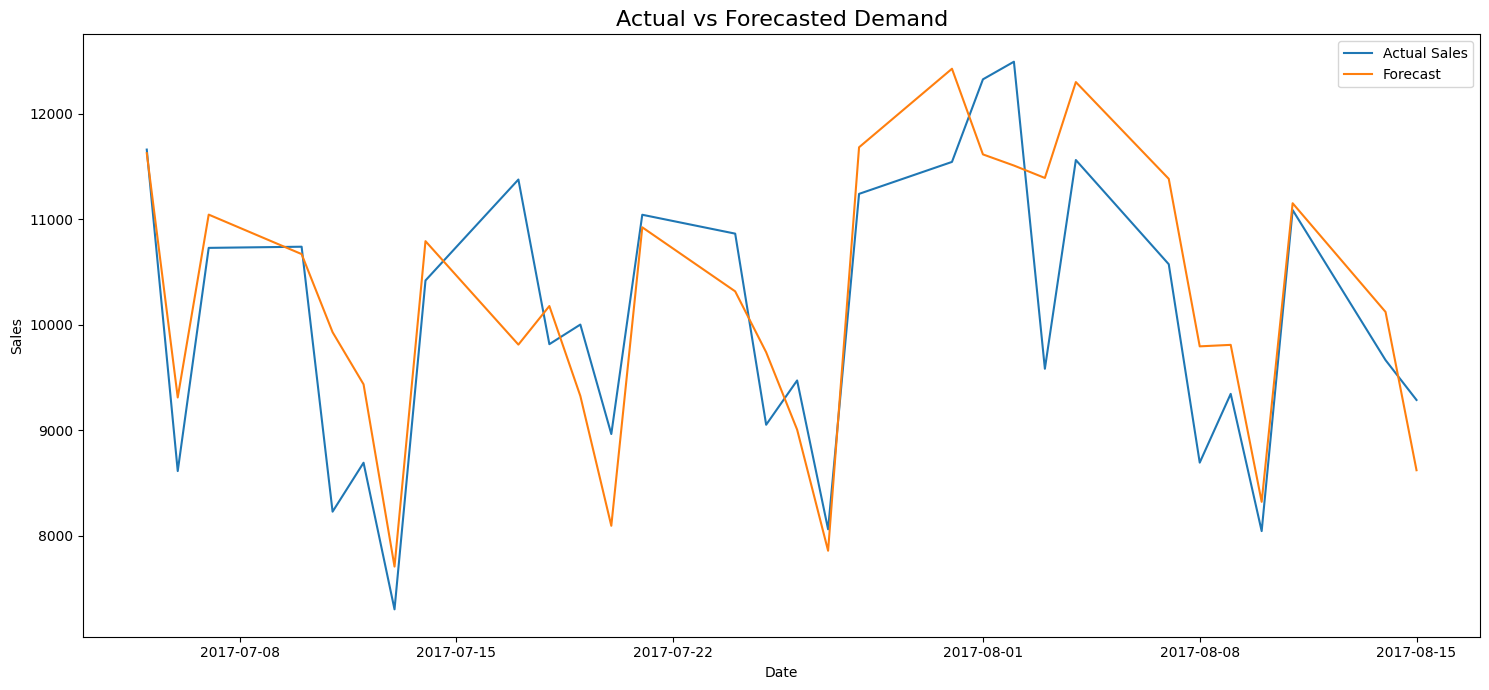

In [15]:
plt.figure(figsize=(15, 7))

plt.plot(
    final_forecast["date"],
    final_forecast["actual_sales"],
    label="Actual Sales"
)

plt.plot(
    final_forecast["date"],
    final_forecast["forecast_sales"],
    label="Forecast"
)

plt.title(
    "Actual vs Forecasted Demand",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()
plt.show()

## 9.11 Forecast Error Over Time

Forecast errors are visualized across the test period to identify systematic periods of overforecasting and underforecasting.

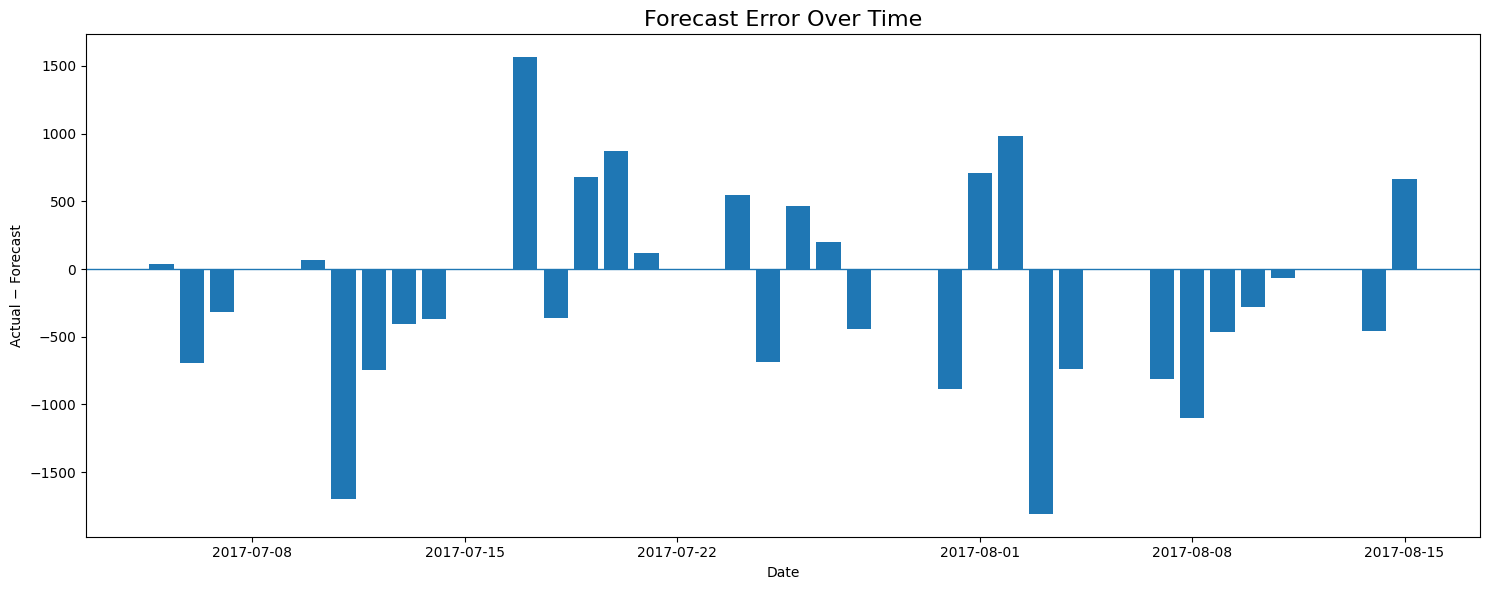

In [16]:
plt.figure(figsize=(15, 6))

plt.bar(
    final_forecast["date"],
    final_forecast["error"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Forecast Error Over Time",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Actual − Forecast")

plt.tight_layout()
plt.show()

## 9.12 Forecast Error Distribution

The distribution of forecast errors is examined to assess whether prediction errors are approximately centered around zero and to identify unusually large errors.

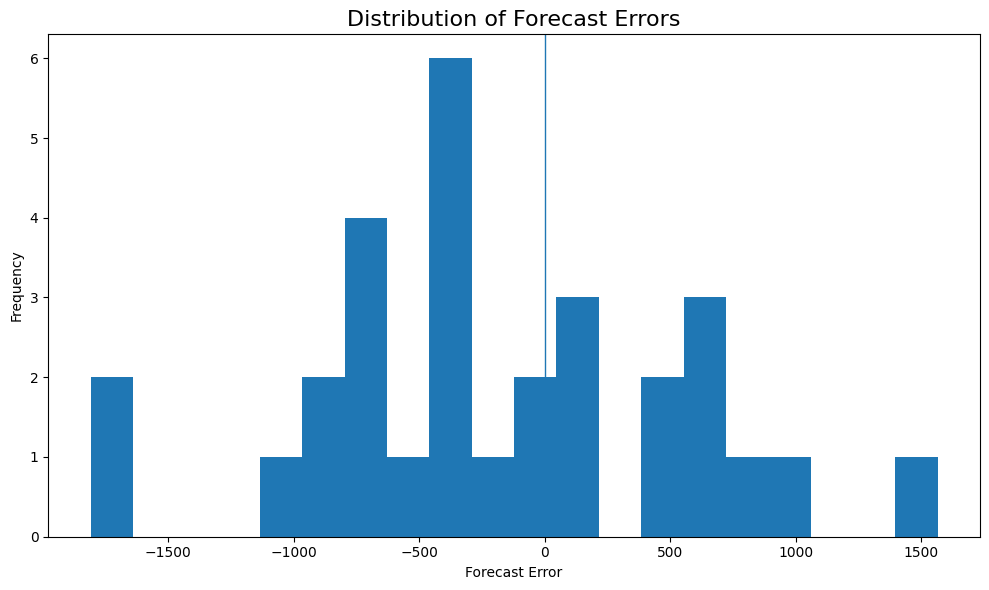

In [17]:
plt.figure(figsize=(10, 6))

plt.hist(
    final_forecast["error"],
    bins=20
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Distribution of Forecast Errors",
    fontsize=16
)

plt.xlabel("Forecast Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [18]:
final_forecast_summary = pd.DataFrame([{
    "Selected Model": final_model,
    "MAE": final_mae,
    "RMSE": final_rmse,
    "MAPE (%)": final_forecast["percentage_error"].mean(),
    "Overforecast Days": overforecast_days,
    "Underforecast Days": underforecast_days,
    "Average Overforecast Error": overforecast_mae,
    "Average Underforecast Error": underforecast_mae
}])

final_forecast_summary

,Selected Model,MAE,RMSE,MAPE (%),Overforecast Days,Underforecast Days,Average Overforecast Error,Average Underforecast Error
0,Original XGBoost,641.55,780.44,6.57,18,12,685.18,576.11


In [19]:
final_forecast.to_csv(
    f"{OUTPUT_PATH}/final_forecast_with_errors.csv",
    index=False
)

error_summary.to_csv(
    f"{OUTPUT_PATH}/final_error_summary.csv",
    index=False
)

largest_errors.to_csv(
    f"{OUTPUT_PATH}/largest_forecast_errors.csv",
    index=False
)

final_forecast_summary.to_csv(
    f"{OUTPUT_PATH}/final_forecast_summary.csv",
    index=False
)

print("Final forecasting outputs saved successfully.")

Final forecasting outputs saved successfully.


# Phase 9 Summary

The forecasting models were consolidated and evaluated using a consistent out-of-sample framework.

The final model was selected based on predictive performance, with MAE used as the primary evaluation metric and RMSE providing additional information about larger forecasting errors.

The final forecast was evaluated against actual demand, and forecast errors were analyzed to distinguish between overforecasting and underforecasting.

The resulting analysis provides both a quantitative assessment of forecasting accuracy and an operational perspective on the consequences of prediction errors.

The final model and forecast outputs have been saved for the business interpretation and portfolio documentation stages.

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Full daily series for Store 45, GROCERY I
parts = []
for chunk in pd.read_csv(
    f"{OUTPUT_PATH}/forecasting_features.csv",
    usecols=["date", "store_nbr", "family", "sales"],
    chunksize=200_000
):
    sel = chunk[(chunk["store_nbr"] == 45) & (chunk["family"] == "GROCERY I")]
    if not sel.empty:
        parts.append(sel)

series = pd.concat(parts)
series["date"] = pd.to_datetime(series["date"])
series = series.drop_duplicates("date").set_index("date")["sales"].asfreq("D")

# Forecasts from each model
xgb_o = pd.read_csv(f"{OUTPUT_PATH}/xgboost_forecast.csv", parse_dates=["date"]).set_index("date")
xgb_t = pd.read_csv(f"{OUTPUT_PATH}/final_xgboost_forecast.csv", parse_dates=["date"]).set_index("date")
sar = pd.read_csv(f"{OUTPUT_PATH}/sarimax_forecast.csv", parse_dates=["date"]).set_index("date")
print("SARIMAX file columns:", sar.columns.tolist())   # check the names
sar_col = [c for c in sar.columns if c not in ("actual_sales", "sales", "actual")][0]

common = xgb_o.index.intersection(xgb_t.index).intersection(sar.index)
print(f"Common evaluation dates: {len(common)} ({common.min().date()} to {common.max().date()})")

actual = series.loc[common]
preds = {
    "Seasonal Naive": series.shift(7).loc[common],
    "SARIMAX": sar.loc[common, sar_col],
    "Original XGBoost": xgb_o.loc[common, "xgboost_forecast"],
    "Tuned XGBoost": xgb_t.loc[common, "forecast_sales"],
}

rows = []
for name, p in preds.items():
    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(actual, p),
        "RMSE": np.sqrt(mean_squared_error(actual, p)),
    })

same_window = pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)
same_window["Rank"] = same_window.index + 1
same_window


SARIMAX file columns: ['actual_sales', 'sarimax_forecast']
Common evaluation dates: 22 (2017-07-17 to 2017-08-15)


,Model,MAE,RMSE,Rank
0,Original XGBoost,677.56,795.69,1
1,Tuned XGBoost,834.37,"1,047.69",2
2,Seasonal Naive,"1,309.86","1,656.28",3
3,SARIMAX,"2,070.18","2,626.44",4
